In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.special import expit

from multiprocessing import Pool, cpu_count
from tqdm import tqdm

import matplotlib.cm as cm
import colormaps as cmaps
import matplotlib.colors as colors
from labellines import labelLines
from matplotlib.cm import brg, ScalarMappable
from matplotlib.colors import (
    LogNorm,
    TwoSlopeNorm,
    LinearSegmentedColormap,
    Normalize,
    ListedColormap,
)
from matplotlib.lines import Line2D

import jax
import jax.numpy as jnp
from jax import random
from jax import vmap

# plt.rcParams.update(
# {"text.usetex": True, "font.family": "Helvetica", "font.size": 8}
# )

plt.rcParams.update(
    {
        "text.usetex": False,
        "font.family": "sans-serif",
        "font.sans-serif": ["Calibri"],
        "font.size": 8,
        "mathtext.fontset": "cm",
    }
)

gnuplot_barve = cm.gnuplot2_r(np.linspace(0.3, 1, 10))
gnuplot_custom = LinearSegmentedColormap.from_list("gnuplot_custom", gnuplot_barve)

brg_barve = cmaps.guppy(np.linspace(0, 1, 10))
bgr_custom = LinearSegmentedColormap.from_list("bgr_custom", brg_barve)

YlGn_barve = cm.YlGn(np.linspace(0, 0.8, 10))
ylgn_custom = LinearSegmentedColormap.from_list("ylgn_custom", YlGn_barve)

markers = ["o", "D", "^", "x", "v", "<", ">", "p", "*", "X"]

set1_list = [
    "#e41a1c",
    "#377eb8",
    "#4daf4a",
    "#984ea3",
    "#ff7f00",
    "#f781bf",
    "#999999",
    "#a65628",
]
bold_list = [
    "#7f3c8d",
    "#11a579",
    "#3969ac",
    "#e73f74",
    "#f2b701",
    "#80ba5a",
    "#e68310",
    "#008695",
    "#cf1c90",
    "#f97b72",
    "#a5aa99",
]

OUT = "/home/kzeleznikar/IJS-F1/Koda/toymodels/plots/"

W = 5.0
from utils import newfig, fd

from ei_open_loop import diag, fd, gam_db, solve, sc

In [50]:
x = np.linspace(-1.0, 1.0, 101)
ea = x
eb = -x

d0 = 0.2
m0 = 0.0
e0, _, _ = diag(ea, eb, d0, m0, uh=0.0, n0=1.0)
n = fd(e0, t=0.08, n0=1.0)

g = 1.5

gs = [
    gam_db(t=0.01, c=0.03, wc=2.0, band="a"),
    gam_db(t=0.25, c=0.03, wc=2.0, band="b"),
]

s = solve(
    x,
    ea,
    eb,
    g=g,
    n=n,
    gs=gs,
    d=d0,
    m=m0,
    uh=0.33,
    n0=1.0,
    dt=0.05,
    td=1.0,
    tm=1.0,
    tol=1.0e-4,
)

print(f"ok={s['ok']} it={s['it']} err={s['err']:.3e}")
print(f"d={s['d']:.8f} m={s['m']:.8f} n0={s['n0']:.8f}")

EI relaxation:   0%|          | 0/200000 [00:00<?, ?it/s]

ok=True it=300 err=7.146e-05
d=0.53131463 m=0.00000000 n0=1.00000000


In [51]:
def scan(
    t1a,
    t2a,
    x,
    ea,
    eb,
    g,
    uh,
    mkgs,
    n0=1.0,
    d0=0.2,
    m0=0.0,
    dt=0.05,
    td=1.0,
    tm=1.0,
    tol=1.0e-7,
    nmax=50000,
    sym=False,
):
    """Scan the steady EI gap over two bath temperatures."""
    t1a = np.asarray(t1a, dtype=float)
    t2a = np.asarray(t2a, dtype=float)
    da = np.zeros((t2a.size, t1a.size))
    ma = np.zeros_like(da)
    er = np.zeros_like(da)
    cv = np.zeros_like(da, dtype=bool)

    e0, _, _ = diag(ea, eb, d0, m0, uh=0.33, n0=n0)
    ni = fd(e0, max(t1a[0], t2a[0]), n0)
    n = ni.copy()
    d = d0
    m = m0

    def one(i, j, n, d, m):
        s = solve(
            x,
            ea,
            eb,
            g=g,
            n=n,
            gs=mkgs(t1a[i], t2a[j]),
            d=max(abs(d), 1.0e-5),
            m=m,
            uh=0.33,
            n0=n0,
            dt=dt,
            td=td,
            tm=tm,
            nmax=nmax,
            tol=tol,
            chk=5,
        )
        return s

    def put(i, j, s):
        da[j, i] = abs(s["d"])
        ma[j, i] = s["m"]
        er[j, i] = s["err"]
        cv[j, i] = s["ok"]

    if sym:
        if t1a.shape != t2a.shape or not np.allclose(t1a, t2a):
            raise ValueError("sym requires identical temperature grids")

        sd = None

        for j in tqdm(range(t2a.size), desc="temperature rows"):
            if sd is None:
                n = ni.copy()
                d = d0
                m = m0
            else:
                n = sd["n"].copy()
                d = sd["d"]
                m = sd["m"]

            sd = one(j, j, n, d, m)
            put(j, j, sd)

            n = sd["n"].copy()
            d = sd["d"]
            m = sd["m"]

            js = range(j + 1, t1a.size)

            for i in tqdm(js, desc="temperature columns", leave=False):
                s = one(i, j, n, d, m)

                n = s["n"].copy()
                d = s["d"]
                m = s["m"]

                put(i, j, s)
                put(j, i, s)

        return {
            "t1": t1a,
            "t2": t2a,
            "d": da,
            "m": ma,
            "err": er,
            "ok": cv,
        }

    for j, t2 in tqdm(enumerate(t2a)):
        js = range(t1a.size) if j % 2 == 0 else range(t1a.size - 1, -1, -1)

        for i in js:
            s = one(i, j, n, d, m)
            n = s["n"]
            d = s["d"]
            m = s["m"]
            put(i, j, s)

    return {"t1": t1a, "t2": t2a, "d": da, "m": ma, "err": er, "ok": cv}

In [52]:
nk = 101
x = (np.arange(nk) + 0.5) / nk
gg = -0.4
rr = 0.7
ea = 0.5 * gg + x
eb = -0.5 * gg - rr * x

t1a = np.linspace(0.01, 2, 10)
t2a = np.linspace(0.01, 2, 10)

c1 = 0.3
c2 = 0.3
wc = 2.0


def mkgs(t1, t2):
    return [
        gam_db(t=t1, c=c1, wc=wc),
        gam_db(t=t2, c=c2, wc=wc),
    ]


z = scan(
    t1a,
    t2a,
    x,
    ea,
    eb,
    g=g,
    uh=0.33,
    mkgs=mkgs,
    n0=1.0,
    d0=0.2,
    m0=0.0,
    dt=0.2,
    td=0.5,
    tm=0.5,
    tol=1.0e-4,
    nmax=10000,
    sym=True,
)

temperature rows:   0%|          | 0/10 [00:00<?, ?it/s]

EI relaxation:   0%|          | 0/10000 [00:00<?, ?it/s]

EI relaxation:   0%|          | 0/10000 [00:00<?, ?it/s]

EI relaxation:   0%|          | 0/10000 [00:00<?, ?it/s]

EI relaxation:   0%|          | 0/10000 [00:00<?, ?it/s]

...

temperature rows:  80%|████████  | 8/10 [00:04<00:00,  3.01it/s]

EI relaxation:   0%|          | 0/10000 [00:00<?, ?it/s]

EI relaxation:   0%|          | 0/10000 [00:00<?, ?it/s]

EI relaxation:   0%|          | 0/10000 [00:00<?, ?it/s]

temperature rows: 100%|██████████| 10/10 [00:04<00:00,  2.01it/s]


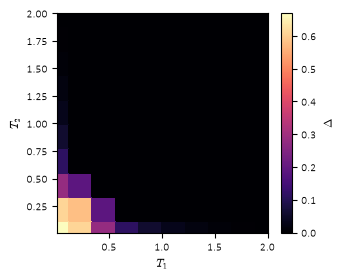

In [53]:
fig, ax = plt.subplots(figsize=(3.47412, 0.82 * 3.47412))
im = ax.pcolormesh(z["t1"], z["t2"], z["d"], shading="nearest", cmap="magma")
im.set_edgecolor("face")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"$\Delta$", rotation=90, labelpad=5)
ax.set_xlabel(r"$T_1$")
ax.set_ylabel(r"$T_2$")
ax.set_xlim(z["t1"][0], z["t1"][-1])
ax.set_ylim(z["t2"][0], z["t2"][-1])
plt.tight_layout()
# fig.savefig("phase_map_test_EI.pdf", bbox_inches="tight")
plt.show()

In [54]:
from tqdm.auto import tqdm, trange
import numpy as np


def occ(e, t, n0):
    if t > 0.0:
        return fd(e, t, n0)

    nk = e.shape[1]
    ne = n0 * nk

    if ne < 0.0 or ne > e.size:
        raise ValueError("invalid filling")

    ef = e.reshape(-1)
    ix = np.argsort(ef)

    n = np.zeros_like(ef)
    j = int(np.floor(ne))
    f = ne - j

    n[ix[:j]] = 1.0

    if f > 1.0e-14 and j < ef.size:
        n[ix[j]] = f

    return n.reshape(e.shape)


def eq_sol(
    ea,
    eb,
    g,
    uh=0.33,
    n0=1.0,
    t=0.0,
    d=0.2,
    m=0.0,
    mix=0.15,
    tol=1.0e-10,
    nit=20000,
    prog=True,
):
    bar = trange(nit, desc="Equilibrium EI", disable=not prog)
    ok = False

    for it in bar:
        e, u, v = diag(ea, eb, d, m, uh=0.33, n0=n0)
        n = occ(e, t, n0)

        ds, ms, nt = sc(n, u, v, g)

        ed = ds - d
        em = ms - m
        er = max(abs(ed), abs(em), abs(nt - n0))

        d += mix * ed
        m += mix * em

        if prog and (it % 100 == 0 or er < tol):
            bar.set_postfix(err=f"{er:.2e}", d=f"{d:.5f}", m=f"{m:.5f}")

        if er < tol:
            ok = True
            break

    e, u, v = diag(ea, eb, d, m, uh=0.33, n0=n0)
    n = occ(e, t, n0)
    ds, ms, nt = sc(n, u, v, g)

    er = max(abs(ds - d), abs(ms - m), abs(nt - n0))

    return {
        "d": d,
        "m": m,
        "n": n,
        "e": e,
        "n0": nt,
        "err": er,
        "ok": ok or er < tol,
        "it": it + 1,
    }

In [55]:
s0 = eq_sol(
    ea,
    eb,
    g=g,
    uh=0.33,
    n0=1.0,
    t=0.0,
    d=0.2,
    m=0.0,
    mix=0.1,
    tol=1.0e-6,
)

d00 = abs(s0["d"])

print("Converged:", s0["ok"])
print("Delta_0:", d00)
print("m_0:", s0["m"])
print("Error:", s0["err"])

Equilibrium EI:   0%|          | 0/20000 [00:00<?, ?it/s]

Converged: True
Delta_0: 0.6691839635555235
m_0: -0.3390586446409829
Error: 9.156096876239417e-07


In [56]:
def nm_sol(
    ea,
    eb,
    g,
    uh,
    n0,
    t,
    m=0.0,
    mix=0.2,
    tol=1.0e-11,
    nit=10000,
):
    for _ in trange(nit, desc="Normal state", disable=True):
        e, u, v = diag(ea, eb, 0.0, m, uh=0.33, n0=n0)
        n = fd(e, t, n0)

        _, ms, _ = sc(n, u, v, g)
        er = abs(ms - m)

        m += mix * (ms - m)

        if er < tol:
            break

    return m


def lin_gap(ea, eb, g, uh, n0, t, m=0.0, ep=1.0e-6):
    m = nm_sol(ea, eb, g, uh, n0, t, m=m)

    e, u, v = diag(ea, eb, ep, m, uh=0.33, n0=n0)
    n = fd(e, t, n0)

    ds, _, _ = sc(n, u, v, g)
    return ds / ep, m


def find_tc(
    ea,
    eb,
    g,
    uh=0.33,
    n0=1.0,
    tlo=1.0e-4,
    thi=2.0,
    nb=50,
):
    ll, ml = lin_gap(ea, eb, g, uh, n0, tlo)
    lh, mh = lin_gap(ea, eb, g, uh, n0, thi)

    if ll <= 1.0:
        raise ValueError("No low-temperature EI instability was found")

    if lh >= 1.0:
        raise ValueError("Increase thi to bracket Tc")

    for _ in trange(nb, desc="Finding Tc"):
        tm = 0.5 * (tlo + thi)
        mm = 0.5 * (ml + mh)

        lm, mm = lin_gap(ea, eb, g, uh, n0, tm, m=mm)

        if lm > 1.0:
            tlo = tm
            ml = mm
        else:
            thi = tm
            mh = mm

    return 0.5 * (tlo + thi)

In [57]:
tc = find_tc(
    ea,
    eb,
    g=g,
    uh=0.33,
    n0=1.0,
    tlo=1.0e-4,
    thi=2.0 * max(t1a.max(), t2a.max()),
)

print("Delta_0:", d00)
print("T_c:", tc)
print("Delta_0 / T_c:", d00 / tc)

Finding Tc:   0%|          | 0/50 [00:00<?, ?it/s]

Delta_0: 0.6691839635555235
T_c: 0.3442585685543389
Delta_0 / T_c: 1.9438411260630606


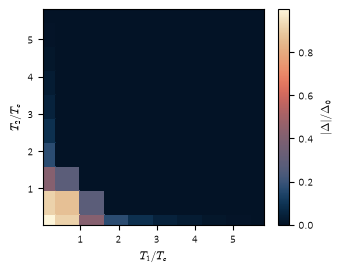

In [58]:
t1n = z["t1"] / tc
t2n = z["t2"] / tc
dn = np.abs(z["d"]) / d00

h = 0.8
fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

im = ax.pcolormesh(
    t1n,
    t2n,
    dn,
    shading="auto",
    cmap=cmaps.lipari,
)
im.set_edgecolor("face")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"$|\Delta|/\Delta_0$", rotation=90, labelpad=5)

ax.set_xlabel(r"$T_1/T_c$")
ax.set_ylabel(r"$T_2/T_c$")
ax.set_xlim(t1n[0], t1n[-1])
ax.set_ylim(t2n[0], t2n[-1])
# fig.savefig("phase_map_test_EI.pdf", bbox_inches="tight")

plt.tight_layout()

casovni convergence?

In [59]:
t1 = 0.001
t2 = 0.5

e0, _, _ = diag(ea, eb, d0, m0, uh=0.33, n0=1.0)
ni = fd(e0, 0.5 * (t1 + t2), n0=1.0)

s = solve(
    x,
    ea,
    eb,
    g=g,
    n=ni,
    gs=mkgs(t1, t2),
    d=d0,
    m=m0,
    uh=0.33,
    n0=1.0,
    dt=0.2,
    td=0.5,
    tm=0.5,
    tol=1.0e-7,
    chk=5,
    nmax=10000,
)

EI relaxation:   0%|          | 0/10000 [00:00<?, ?it/s]

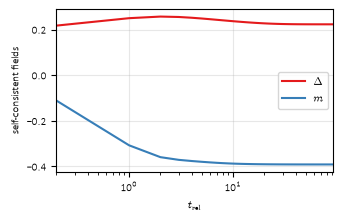

In [60]:
hs = s["hist"]
tt = np.asarray(hs["t"])

h = 0.65
fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

ax.plot(tt, hs["d"], color=set1_list[0], label=r"$\Delta$")
ax.plot(tt, hs["m"], color=set1_list[1], label=r"$m$")
ax.set_xscale("log")
ax.set_xlabel(r"$t_{\mathrm{rel}}$")
ax.set_ylabel(r"self-consistent fields")
ax.set_xlim(tt[0], tt[-1])
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

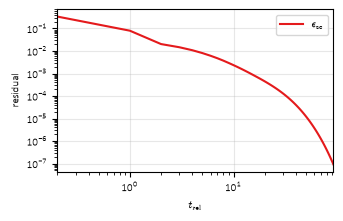

In [61]:
er = np.maximum(np.asarray(hs["err"]), 1.0e-16)

h = 0.65
fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

ax.semilogy(
    tt,
    er,
    color=set1_list[0],
    label=r"$\epsilon_{\mathrm{sc}}$",
)

ax.set_xlabel(r"$t_{\mathrm{rel}}$")
ax.set_ylabel(r"residual")
ax.set_xscale("log")

ax.set_xlim(tt[0], tt[-1])
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

In [62]:
ta = np.linspace(
    max(1.0e-4, 0.25 * min(t1, t2)),
    2.0 * max(t1, t2),
    200,
)

qa = np.empty_like(ta)

for j, t in enumerate(tqdm(ta, desc="Fitting FD")):
    nt = fd(s["e"], t, n0=1.0)
    qa[j] = np.mean((s["n"] - nt) ** 2)

te = ta[np.argmin(qa)]
nf = fd(s["e"], te, n0=1.0)

print("Best FD temperature:", te)
print("FD RMS difference:", np.sqrt(qa.min()))

Fitting FD:   0%|          | 0/200 [00:00<?, ?it/s]

Best FD temperature: 0.3067060301507537
FD RMS difference: 0.03373214752855514


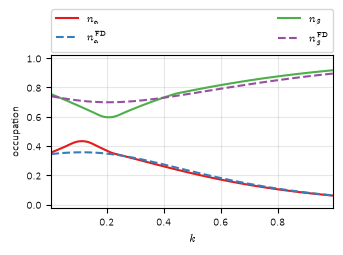

In [63]:
h = 0.75
fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

ax.plot(
    x,
    s["n"][0],
    color=set1_list[0],
    label=r"$n_\alpha$",
)

ax.plot(
    x,
    nf[0],
    "--",
    color=set1_list[1],
    label=r"$n_\alpha^{\mathrm{FD}}$",
)

ax.plot(
    x,
    s["n"][1],
    color=set1_list[2],
    label=r"$n_\beta$",
)

ax.plot(
    x,
    nf[1],
    "--",
    color=set1_list[3],
    label=r"$n_\beta^{\mathrm{FD}}$",
)

ax.set_xlabel(r"$k$")
ax.set_ylabel(r"occupation")
ax.set_xlim(x[0], x[-1])
ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.3)

ax.legend(
    bbox_to_anchor=(0, 1.02, 1, 0.2),
    loc="lower left",
    mode="expand",
    borderaxespad=0,
    ncol=2,
)

plt.tight_layout()
plt.savefig("distributionsEI.pdf")

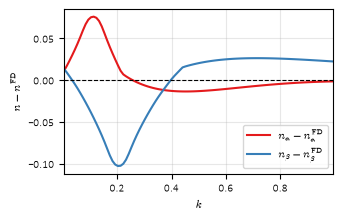

In [64]:
h = 0.65
fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

ax.plot(
    x,
    s["n"][0] - nf[0],
    color=set1_list[0],
    label=r"$n_\alpha-n_\alpha^{\mathrm{FD}}$",
)

ax.plot(
    x,
    s["n"][1] - nf[1],
    color=set1_list[1],
    label=r"$n_\beta-n_\beta^{\mathrm{FD}}$",
)

ax.axhline(0.0, color="black", linewidth=0.8, linestyle="--")

ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$n-n^{\mathrm{FD}}$")
ax.set_xlim(x[0], x[-1])
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

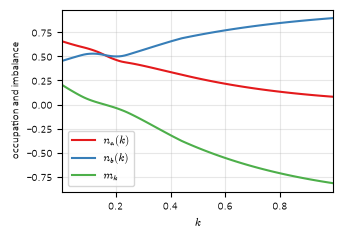

In [65]:
na = s["u"] ** 2 * s["n"][0] + s["v"] ** 2 * s["n"][1]
nb = s["v"] ** 2 * s["n"][0] + s["u"] ** 2 * s["n"][1]
mk = na - nb

h = 0.7
fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

ax.plot(x, na, color=set1_list[0], label=r"$n_a(k)$")
ax.plot(x, nb, color=set1_list[1], label=r"$n_b(k)$")
ax.plot(x, mk, color=set1_list[2], label=r"$m_k$")

ax.set_xlabel(r"$k$")
ax.set_ylabel(r"occupation and imbalance")
ax.set_xlim(x[0], x[-1])
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import utils as eq
import ei_open_loop as op

In [3]:
nk = 15

eg = 0.4
ta = 1.0
tb = -0.3

v = 1.5
n0 = 1.0
t = 0.10

bd = eq.sq(
    nk=nk,
    d=eg,
    ta=ta,
    tb=tb,
)

p = eq.Pars(
    v=v,
    t=t,
    n=n0,
    uh=None,
)

se = eq.solve(
    bd,
    p,
    y0=(0.5, 0.0, 0.0),
)

print("Equilibrium solution")
print("Delta =", se.d)
print("m     =", se.m)
print("mu    =", se.mu)

Equilibrium solution
Delta = 0.2328508404188469
m     = -0.23935103838924734
mu    = 0.569708324055858


In [4]:
def seg(a, b, nq):
    z = np.linspace(0.0, 1.0, nq, endpoint=False)
    return a[None, :] + z[:, None] * (b - a)[None, :]


nq = 100

kg = np.array([0.0, 0.0])
kx = np.array([np.pi, 0.0])
km = np.array([np.pi, np.pi])

kp = np.vstack(
    (
        seg(kg, kx, nq),
        seg(kx, km, nq),
        seg(km, kg, nq),
        kg[None, :],
    )
)

ks = np.concatenate(
    (
        [0.0],
        np.cumsum(np.linalg.norm(np.diff(kp, axis=0), axis=1)),
    )
)

cc = np.cos(kp[:, 0]) + np.cos(kp[:, 1])

ea0 = 0.5 * eg - 2.0 * ta * cc
eb0 = -0.5 * eg - 2.0 * tb * cc

na = 0.5 * (n0 + se.m)
nb = 0.5 * (n0 - se.m)

eah = ea0 + v * nb
ebh = eb0 + v * na

av = 0.5 * (eah + ebh)
xi = 0.5 * (eah - ebh)
ek = np.sqrt(xi**2 + se.d**2)

ep = av + ek
em = av - ek

findfont: Failed to find font weight normal, now using 300.
findfont: Failed to find font weight normal, now using 300.


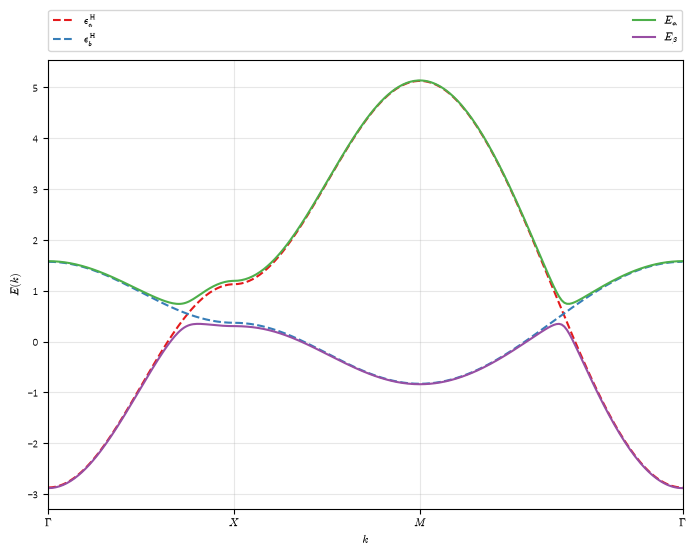

In [5]:
h = 0.8
fig, ax = plt.subplots(figsize=(7, h * 7))

ax.plot(
    ks,
    eah,
    "--",
    color=set1_list[0],
    label=r"$\epsilon_a^{\rm H}$",
)

ax.plot(
    ks,
    ebh,
    "--",
    color=set1_list[1],
    label=r"$\epsilon_b^{\rm H}$",
)

ax.plot(
    ks,
    ep,
    color=set1_list[2],
    label=r"$E_\alpha$",
)

ax.plot(
    ks,
    em,
    color=set1_list[3],
    label=r"$E_\beta$",
)

ix = np.array([0, nq, 2 * nq, 3 * nq])

ax.set_xticks(ks[ix])
ax.set_xticklabels(
    [
        r"$\Gamma$",
        r"$X$",
        r"$M$",
        r"$\Gamma$",
    ]
)

ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$E(k)$")
ax.set_xlim(ks[0], ks[-1])
ax.grid(alpha=0.3)

ax.legend(
    bbox_to_anchor=(0, 1.02, 1, 0.2),
    loc="lower left",
    mode="expand",
    borderaxespad=0,
    ncol=2,
)

plt.tight_layout()

In [6]:
nm = bd.ea.size
x = np.arange(nm, dtype=float)

di = max(0.7 * se.d, 1.0e-3)
mi = np.clip(se.m + 0.05, -0.95, 0.95)

ei, _, _ = op.diag(
    bd.ea,
    bd.eb,
    di,
    mi,
    uh=v,
    n0=n0,
)

ni = op.fd(
    ei,
    t=1.5 * t,
    n0=n0,
)

In [10]:
c = 0.05
wc = 5.0

gs = [
    op.gam_db(t=t, c=c, wc=wc, band="a"),
    op.gam_db(t=t, c=c, wc=wc, band="b"),
]

sb = op.solve(
    x,
    bd.ea,
    bd.eb,
    g=v,
    n=ni,
    gs=gs,
    d=di,
    m=mi,
    uh=v,
    n0=n0,
    dt=0.2,
    td=0.5,
    tm=0.5,
    nmax=50000,
    tol=1.0e-6,
    chk=5,
)

EI relaxation:   0%|          | 0/50000 [00:00<?, ?it/s]

In [11]:
ze = eq.data(bd, p, se.y)

ee = np.stack((
    ze["ep"],
    ze["em"],
))

nf = op.fd(
    sb["e"],
    t=t,
    n0=n0,
)

ed = abs(sb["d"] - se.d)
em = abs(sb["m"] - se.m)
ee_er = np.max(np.abs(sb["e"] - ee))
fd_er = np.max(np.abs(sb["n"] - nf))

print("Comparison")
print(f"Delta equilibrium = {se.d:.10f}")
print(f"Delta baths       = {sb['d']:.10f}")
print(f"Delta difference  = {ed:.3e}")
print()
print(f"m equilibrium     = {se.m:.10f}")
print(f"m baths           = {sb['m']:.10f}")
print(f"m difference      = {em:.3e}")
print()
print(f"Energy difference = {ee_er:.3e}")
print(f"FD difference     = {fd_er:.3e}")
print(f"Bath residual     = {sb['err']:.3e}")
print(f"Bath converged    = {sb['ok']}")

Comparison
Delta equilibrium = 0.2328508404
Delta baths       = 0.2323195053
Delta difference  = 5.313e-04

m equilibrium     = -0.2393510384
m baths           = -0.2394095642
m difference      = 5.853e-05

Energy difference = 5.331e-04
FD difference     = 6.990e-04
Bath residual     = 9.997e-07
Bath converged    = True


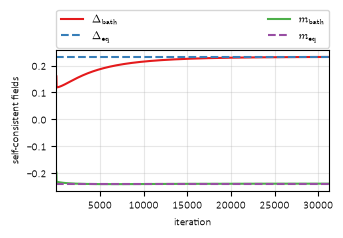

In [12]:
hs = sb["hist"]
it = np.asarray(hs["it"])

h = 0.7
fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

ax.plot(
    it,
    hs["d"],
    color=set1_list[0],
    label=r"$\Delta_{\rm bath}$",
)

ax.axhline(
    se.d,
    color=set1_list[1],
    linestyle="--",
    label=r"$\Delta_{\rm eq}$",
)

ax.plot(
    it,
    hs["m"],
    color=set1_list[2],
    label=r"$m_{\rm bath}$",
)

ax.axhline(
    se.m,
    color=set1_list[3],
    linestyle="--",
    label=r"$m_{\rm eq}$",
)

ax.set_xlabel(r"iteration")
ax.set_ylabel(r"self-consistent fields")
ax.set_xlim(it[0], it[-1])
ax.grid(alpha=0.3)

ax.legend(
    bbox_to_anchor=(0, 1.02, 1, 0.2),
    loc="lower left",
    mode="expand",
    borderaxespad=0,
    ncol=2,
)

plt.tight_layout()